# 10-High-Volume Log Aggregation (Grafana Loki)

In Lesson 09, we engineered high-definition visual dashboards using Grafana and Prometheus. We successfully monitored mathematical time-series metrics like $P_{99}$ latency and Tokens Per Second (TPS).

Metrics are phenomenal for alerting. If your GPU cluster fails, Prometheus will instantly turn the dashboard red. However, metrics tell you *that* a system is failing; they do not tell you *why* it is failing. To debug a specific Python stack trace (e.g., `CUDA Out of Memory` or a `Tensor Shape Mismatch`), you must read the raw, unstructured application **Logs**.

Historically, enterprises used systems like Elasticsearch to aggregate logs. Elasticsearch performs **Full-Text Indexing**—it analyzes and indexes every single word in your log stream. For ML applications generating gigabytes of dense JSON payloads and stack traces per hour, this approach is mathematically ruinous, costing hundreds of thousands of dollars in RAM and storage overhead.

To engineer a cost-effective, high-volume log aggregation pipeline, we implement **Grafana Loki**. Loki uses a radically different mathematical approach: it only indexes metadata *labels* (exactly like Prometheus) and compresses the raw text into cheap object storage. We will use **Promtail** to actively scrape our local filesystem logs and pipe them into Loki for high-speed triage.

## 1. The Mathematics of Log Indexing & Storage Physics

### The Ruin of Full-Text Indexing (Elasticsearch)

Let a single log line be a text string $L$ containing $W$ words. In a full-text search engine, the system builds an inverted index mapping every word back to the document.
If an ML inference node generates $100\text{ GB}$ of log data per day, the inverted index will easily consume $150\text{ GB}$ of highly expensive RAM.


$$\text{Storage Cost}_{Elastic} \approx \mathcal{O}(\vert{}W\vert{} \times \text{Log Volume})$$

### The Label-Only Architecture (Grafana Loki)

Loki refuses to index the text payload. Instead, it groups log lines into compressed "streams" defined solely by a mathematical vector of key-value labels, mirroring the exact schema of Prometheus:


$$Stream = \langle \{ \text{app="inference-api"}, \text{level="error"}, \text{gpu="0"} \}, [ (t_1, \text{log\_text}_1), (t_2, \text{log\_text}_2) ] \rangle$$

Because Loki only indexes the tiny label dictionary, the index size drops from gigabytes to megabytes.


$$\text{Storage Cost}_{Loki} \approx \mathcal{O}(\text{Cardinality of Labels})$$

### LogQL (Log Query Language)

To query the logs, Loki uses a two-phase mathematical pipeline:

1. **Label Matcher (Index Phase):** Instantly isolates the correct compressed chunk of logs using the tiny index.
`{app="inference-api", level="error"}`
2. **Line Filter (Brute-Force Phase):** Decompresses that specific chunk and executes a highly optimized regex or string match in parallel across the CPU cores.
`|= "CUDA out of memory"`

## 2. Imperative Execution: Simulating the MLOps JSON Log Stream

In enterprise MLOps, we do not print unstructured strings (`print("error")`). We log strictly formatted JSON payloads, allowing our aggregation agents to parse specific fields (like `level` or `trace_id`) into Loki labels.

Let's use Python to programmatically generate a massive, rolling JSON log file that simulates a high-throughput ML API experiencing occasional fatal errors.

In [1]:
import os
import json
import time
import random
from datetime import datetime, timezone

print("--- 🚀 Initializing MLOps Log Stream Sandbox ---")

log_sandbox = "./loki_sandbox"
os.makedirs(log_sandbox, exist_ok=True)
log_file_path = os.path.join(log_sandbox, "inference_api.log")

# 1. 📝 Simulate a structured JSON logging engine
def generate_log_stream(num_lines=1000):
    error_types = [
        "RuntimeError: CUDA out of memory. Tried to allocate 2.00 GiB.",
        "ValueError: Tensor shape mismatch. Expected (32, 224, 224), got (32, 256, 256).",
        "TimeoutError: Redis Feature Store connection dropped."
    ]
    
    print(f"   [SYSTEM] Generating {num_lines} unstructured JSON logs at {log_file_path}...")
    
    with open(log_file_path, "w") as f:
        for i in range(num_lines):
            # 95% of traffic is healthy, 5% results in fatal ML errors
            is_error = random.random() < 0.05
            
            log_entry = {
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "app": "inference-api",
                "env": "production",
                "level": "ERROR" if is_error else "INFO",
                "trace_id": f"trc_{random.randint(10000, 99999)}",
                "latency_ms": round(random.uniform(50, 200) if not is_error else random.uniform(2000, 5000), 2),
                "message": random.choice(error_types) if is_error else "Inference forward pass successful."
            }
            
            # Write the strict JSON payload to the POSIX filesystem
            f.write(json.dumps(log_entry) + "\n")

generate_log_stream()
print("   ✅ Simulated Log Stream successfully generated.")

--- 🚀 Initializing MLOps Log Stream Sandbox ---
   [SYSTEM] Generating 1000 unstructured JSON logs at ./loki_sandbox/inference_api.log...
   ✅ Simulated Log Stream successfully generated.


## 3. Declarative Execution: Promtail & Loki Architecture Matrix

To scrape these logs, we deploy **Promtail** (the agent) and **Loki** (the database).

Promtail runs on the local machine. It tails the `inference_api.log` file, parses the JSON, extracts the `app` and `level` fields as indexed labels, and ships the compressed data to Loki.

In [2]:
import yaml

print("\n--- ⚡ Compiling Declarative Log Aggregation Infrastructure ---")

# 1. 📝 Compile the Promtail Scraping Configuration
promtail_config = """
server:
  http_listen_port: 9080
  grpc_listen_port: 0

positions:
  filename: /tmp/positions.yaml # Tracks the tail position in case of restart

clients:
  - url: http://loki:3100/loki/api/v1/push # Push logs to the centralized Loki engine

scrape_configs:
- job_name: system
  static_configs:
  - targets:
      - localhost
    labels:
      job: ml_inference_logs # Static label
      __path__: /var/log/mlops/*log # Path to tail on the local file system
      
  # 🧠 The Log Pipeline: Parse JSON and promote specific fields to indexed labels
  pipeline_stages:
  - json:
      expressions:
        level: level
        app: app
  - labels:
      level:
      app:
"""

promtail_path = os.path.join(log_sandbox, "promtail-config.yaml")
with open(promtail_path, "w") as f:
    f.write(promtail_config.strip())

# 2. 📝 Compile the Docker Compose Blueprint
loki_compose = {
    "version": "3.8",
    "services": {
        "loki": {
            "image": "grafana/loki:latest",
            "container_name": "mlops_loki_db",
            "ports": ["3100:3100"],
            "command": "-config.file=/etc/loki/local-config.yaml"
        },
        "promtail": {
            "image": "grafana/promtail:latest",
            "container_name": "mlops_promtail_agent",
            "volumes": [
                # Mount the local log file directly into the Promtail container
                f"./inference_api.log:/var/log/mlops/inference_api.log",
                f"./promtail-config.yaml:/etc/promtail/config.yml"
            ],
            "command": "-config.file=/etc/promtail/config.yml",
            "depends_on": ["loki"]
        }
    }
}

compose_path = os.path.join(log_sandbox, "docker-compose.yml")
with open(compose_path, "w") as f:
    yaml.dump(loki_compose, f, default_flow_style=False)

print(f"   ✅ Promtail Configuration Compiled: {promtail_path}")
print(f"   ✅ Docker Compose Matrix Compiled: {compose_path}")

print("\n--- 🛠️ Operational Boot Instructions ---")
print("To boot the log aggregation pipeline locally:")
print(f"   1. cd {log_sandbox} && docker compose up -d")
print("   2. Connect Grafana (from Lesson 09) to the Loki Datasource at http://loki:3100")
print("   3. Execute this LogQL query in the Grafana Explore tab to instantly isolate ML failures:")
print("      {app=\"inference-api\", level=\"ERROR\"} |= \"CUDA out of memory\"")


--- ⚡ Compiling Declarative Log Aggregation Infrastructure ---
   ✅ Promtail Configuration Compiled: ./loki_sandbox/promtail-config.yaml
   ✅ Docker Compose Matrix Compiled: ./loki_sandbox/docker-compose.yml

--- 🛠️ Operational Boot Instructions ---
To boot the log aggregation pipeline locally:
   1. cd ./loki_sandbox && docker compose up -d
   2. Connect Grafana (from Lesson 09) to the Loki Datasource at http://loki:3100
   3. Execute this LogQL query in the Grafana Explore tab to instantly isolate ML failures:
      {app="inference-api", level="ERROR"} |= "CUDA out of memory"


## 4. Visualizing the Indexing Physics (Elasticsearch vs. Loki)

To deeply understand why MLOps infrastructure relies on Loki over legacy systems, let's graph the mathematical distinction between Full-Text Indexing and Label-Only Indexing.

/tmp/ipykernel_24144/508707375.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_24144/508707375.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 5.0), 5.0, 1.5, fill=True, color='white', edgecolor='black', linewidth=2))
/tmp/ipykernel_24144/508707375.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((7.5, 0.5), 6.0, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_24144/508707375.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((8.0, 5.0), 5.0, 1.5, fill=True

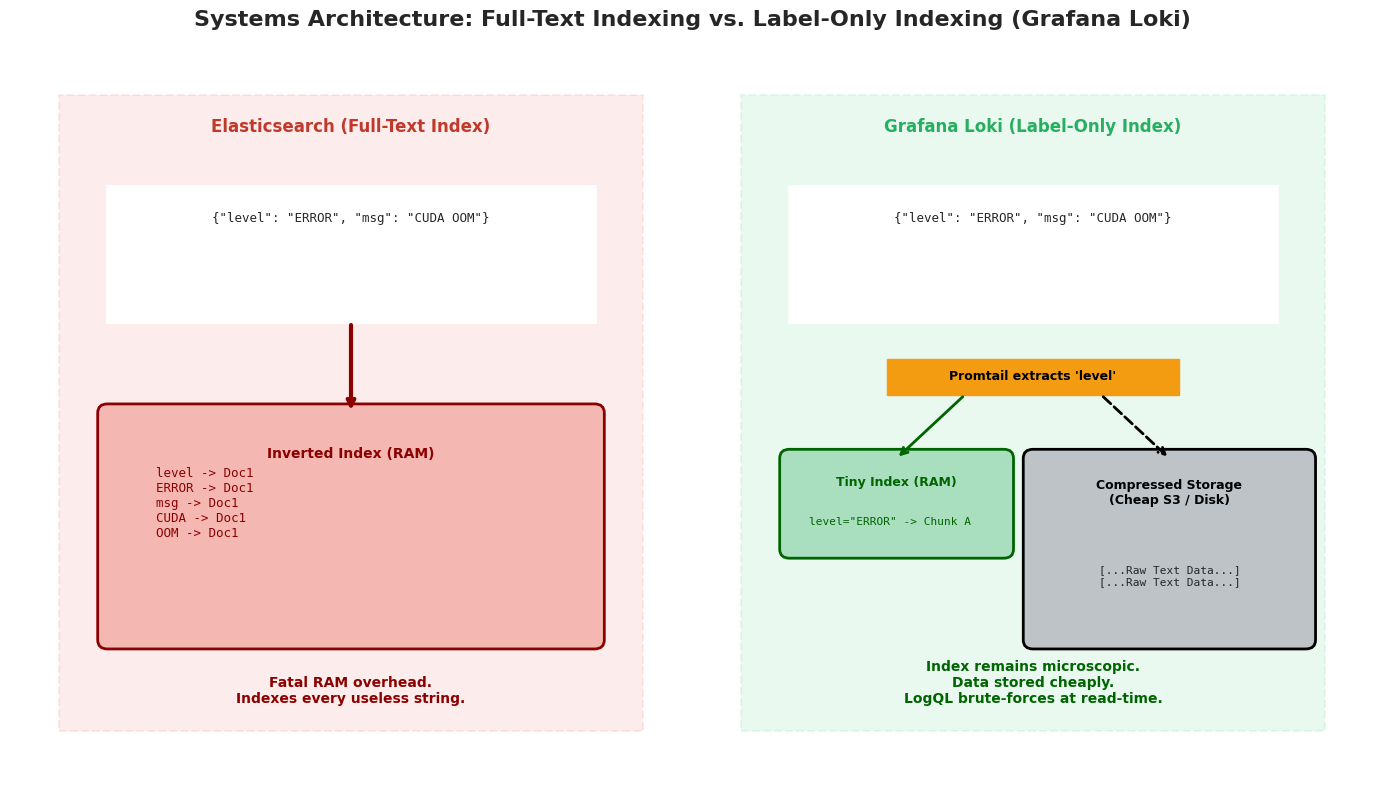

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Full-Text Indexing vs. Label-Only Indexing (Grafana Loki)", fontsize=16, fontweight='bold')
ax.axis('off')

# ----------------------------------------------------
# LEFT: FULL-TEXT INDEXING (Elasticsearch)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 0.5), 6.0, 7.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(3.5, 7.1, "Elasticsearch (Full-Text Index)", ha='center', color='#c0392b', fontweight='bold', fontsize=12)

# The Log Document
ax.add_patch(patches.Rectangle((1.0, 5.0), 5.0, 1.5, fill=True, color='white', edgecolor='black', linewidth=2))
ax.text(3.5, 6.1, '{"level": "ERROR", "msg": "CUDA OOM"}', ha='center', fontfamily='monospace', fontsize=9)

# The Massive Index
ax.add_patch(patches.FancyBboxPatch((1.0, 1.5), 5.0, 2.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='darkred', facecolor='#f5b7b1'))
ax.text(3.5, 3.5, "Inverted Index (RAM)", ha='center', color='darkred', fontweight='bold', fontsize=10)

ax.text(1.5, 3.0, "level -> Doc1\nERROR -> Doc1\nmsg -> Doc1\nCUDA -> Doc1\nOOM -> Doc1", ha='left', va='center', fontfamily='monospace', fontsize=9, color='darkred')

ax.annotate("", xy=(3.5, 4.0), xytext=(3.5, 5.0), arrowprops=dict(arrowstyle="->", lw=3, color="darkred"))
ax.text(3.5, 0.8, "Fatal RAM overhead.\nIndexes every useless string.", ha='center', color='darkred', fontweight='bold', fontsize=10)


# ----------------------------------------------------
# RIGHT: LABEL-ONLY INDEXING (Grafana Loki)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((7.5, 0.5), 6.0, 7.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(10.5, 7.1, "Grafana Loki (Label-Only Index)", ha='center', color='#27ae60', fontweight='bold', fontsize=12)

# The Log Document
ax.add_patch(patches.Rectangle((8.0, 5.0), 5.0, 1.5, fill=True, color='white', edgecolor='black', linewidth=2))
ax.text(10.5, 6.1, '{"level": "ERROR", "msg": "CUDA OOM"}', ha='center', fontfamily='monospace', fontsize=9)

# Promtail Extraction
ax.add_patch(patches.Rectangle((9.0, 4.2), 3.0, 0.4, fill=True, color='#f39c12', edgecolor='black'))
ax.text(10.5, 4.4, "Promtail extracts 'level'", ha='center', va='center', color='black', fontsize=9, fontweight='bold')

# The Tiny Index
ax.add_patch(patches.FancyBboxPatch((8.0, 2.5), 2.2, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='darkgreen', facecolor='#a9dfbf'))
ax.text(9.1, 3.2, "Tiny Index (RAM)", ha='center', color='darkgreen', fontweight='bold', fontsize=9)
ax.text(8.2, 2.8, "level=\"ERROR\" -> Chunk A", ha='left', va='center', fontfamily='monospace', fontsize=8, color='darkgreen')

# Compressed Object Storage
ax.add_patch(patches.FancyBboxPatch((10.5, 1.5), 2.8, 2.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#bdc3c7'))
ax.text(11.9, 3.0, "Compressed Storage\n(Cheap S3 / Disk)", ha='center', color='black', fontweight='bold', fontsize=9)
ax.text(11.9, 2.2, "[...Raw Text Data...]\n[...Raw Text Data...]", ha='center', va='center', fontfamily='monospace', fontsize=8)

# Routing vectors
ax.annotate("", xy=(9.1, 3.5), xytext=(9.8, 4.2), arrowprops=dict(arrowstyle="->", lw=2, color="darkgreen"))
ax.annotate("", xy=(11.9, 3.5), xytext=(11.2, 4.2), arrowprops=dict(arrowstyle="->", lw=2, color="black", linestyle="--"))

ax.text(10.5, 0.8, "Index remains microscopic.\nData stored cheaply.\nLogQL brute-forces at read-time.", ha='center', color='darkgreen', fontweight='bold', fontsize=10)

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy

Think of Grafana Loki vs. Elasticsearch like **Organizing a Massive Corporate Library**:

* **Elasticsearch (The Exhaustive Librarian):** The librarian takes every single book (Log File) in the building, reads every single word, and writes down the exact page number of every word in a massive master catalog (**The Inverted Index**). When you ask for the phrase *"CUDA out of memory,"* the librarian finds it instantly. However, the master catalog is now so gigantic that it takes up half the building, and you are bankrupt paying for the paper to print the catalog (**RAM Costs**).
* **Grafana Loki (The Smart Archivist):** The archivist refuses to read the books. Instead, they just look at the cover. They put all the books by the API team in one box, and label the box: `app="inference-api"`, `level="error"` (**The Label-Only Index**). They shove the box into a cheap, dark basement (**Object Storage**).
* The catalog is tiny. It only tracks the labels on the boxes.
* When you query `{app="inference-api", level="error"} |= "CUDA out of memory"`, the archivist runs to the basement, grabs the exact box, dumps the books on a table, and uses a high-speed scanner (**The Line Filter**) to rip through the pages right then and there.
* It requires a bit more CPU power at the exact moment of the search, but it saves the company millions of dollars in continuous memory overhead.